<a href="https://colab.research.google.com/github/0IBSIP/Retail-Sales-EDA/blob/main/Retail_Sales_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-1 Retail Sales Exploratory Data Analysis

##1. Introduction

This project performs Exploratory Data Analysis (EDA) on a retail sales dataset.

The objective is to analyze sales trends, customer demographics, product performance, and relationships between numerical variables using Python.

## Objectives

- Inspect and understand the dataset
- Clean missing and inconsistent data
- Calculate descriptive statistics
- Analyze monthly and quarterly sales trends
- Study customer age groups and gender distribution
- Identify the top 10 best-selling products
- Analyze revenue by product category
- Study correlations between numerical variables
- Identify additional business insights
- Provide actionable business recommendations

## Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

# 2. Import Libraries

The required Python libraries are imported for data manipulation, numerical analysis, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# 3. Dataset Loading

The retail sales dataset is loaded into a Pandas DataFrame for analysis.

In [ ]:

from google.colab import files

uploaded = files.upload()

files.download('/content/retail_sales_dataset.csv')

Saving retail_sales_dataset.csv to retail_sales_dataset (3).csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4310, 21)


,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


# 4. Initial Data Inspection

The dataset is inspected to understand its size, columns, data types, and missing values.

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

print("Missing Value Percentage:")
print(missing_percentage)

Number of Rows: 4310
Number of Columns: 21

Column Names:
['order_id', 'order_date', 'customer_id', 'customer_name', 'age', 'gender', 'region', 'city', 'product_category', 'product_name', 'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit', 'shipping_cost', 'payment_method', 'customer_satisfaction', 'return_flag', 'order_status', 'days_to_ship']

Data Types:
order_id                  object
order_date                object
customer_id               object
customer_name             object
age                      float64
gender                    object
region                    object
city                      object
product_category          object
product_name              object
quantity                 float64
unit_price               float64
discount_pct             float64
sales_amount             float64
profit                   float64
shipping_cost            float64
payment_method            object
customer_satisfaction    float64
return_flag               obje

# 5. Data Cleaning

The dataset is cleaned by converting dates into datetime format, standardizing gender values, handling invalid ages, filling missing numerical values, and removing duplicate records.

In [ ]:
# Convert order_date into datetime
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    errors="coerce"
)

# Standardize gender values
df["gender"] = df["gender"].str.strip().str.title()

# Replace invalid ages with NaN
df.loc[(df["age"] < 0) | (df["age"] > 100), "age"] = np.nan

# Fill missing age with median
df["age"] = df["age"].fillna(df["age"].median())

# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Check duplicates
print("Duplicate Rows Before:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Duplicate Rows After:", df.duplicated().sum())
print("Total Missing Values:", df.isnull().sum().sum())

Duplicate Rows Before: 109
Duplicate Rows After: 0
Total Missing Values: 12


In [ ]:
print("Final Dataset Shape:", df.shape)
print("Order Date Data Type:", df["order_date"].dtype)
print("Total Missing Values:", df.isnull().sum().sum())

Final Dataset Shape: (4201, 21)
Order Date Data Type: datetime64[ns]
Total Missing Values: 12


In [ ]:
df.isnull().sum()

,0
order_id,1
order_date,1
customer_id,1
customer_name,1
age,0
gender,1
region,1
city,1
product_category,1
product_name,1


# 6. Descriptive Statistics

Descriptive statistics are calculated for all numerical variables using Mean, Median, Mode, and Standard Deviation.

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

statistics = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Mode": numeric_df.mode().iloc[0],
    "Standard Deviation": numeric_df.std()
})

statistics.round(2)

,Mean,Median,Mode,Standard Deviation
age,34.21,34.00,34.00,11.67
quantity,7.36,5.00,5.00,43.42
unit_price,10700.71,2245.26,103.75,17407.19
discount_pct,0.20,0.21,0.21,0.12
sales_amount,62908.68,9647.73,10874.57,319475.60
profit,11788.21,3168.26,6.89,53346.00
shipping_cost,63.38,63.46,42.69,18.32
customer_satisfaction,3.02,3.00,3.00,1.35
days_to_ship,5.63,6.00,6.00,4.15


### Observation

The descriptive statistics provide an overview of the central tendency and variability of the numerical variables. Comparing the mean and median helps identify possible skewness, while standard deviation indicates the spread of the data.

# 7. Monthly Sales Trend

Monthly sales are analyzed to identify changes in sales performance over time.

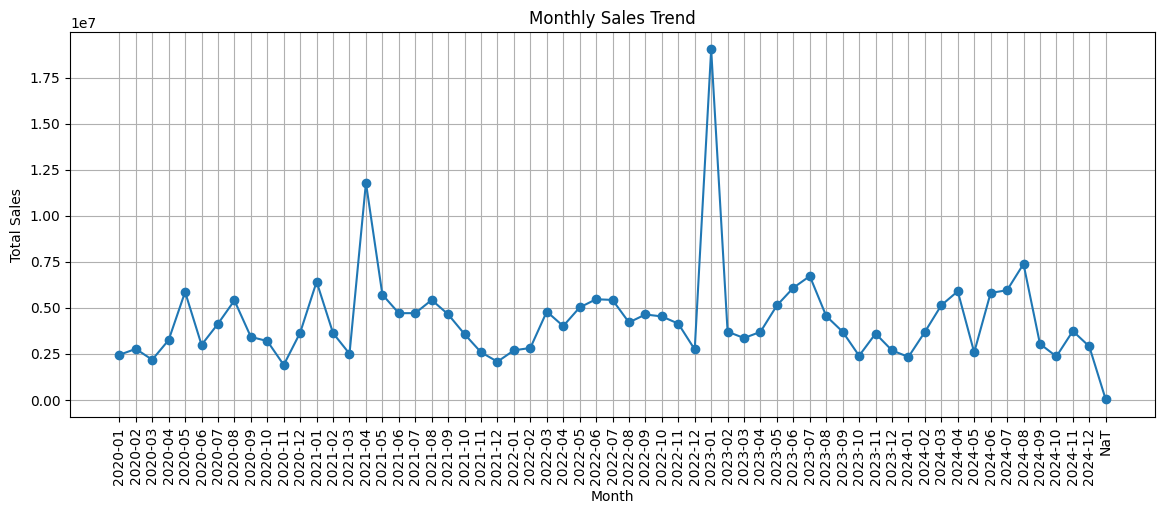

In [ ]:
df["Month"] = df["order_date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["sales_amount"].sum()

plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

### Observation

The monthly sales trend shows fluctuations in sales across different months. This analysis helps identify periods of relatively high and low customer demand.

# 8. Quarterly Sales Trend

Sales performance is grouped into quarters to understand broader seasonal trends.

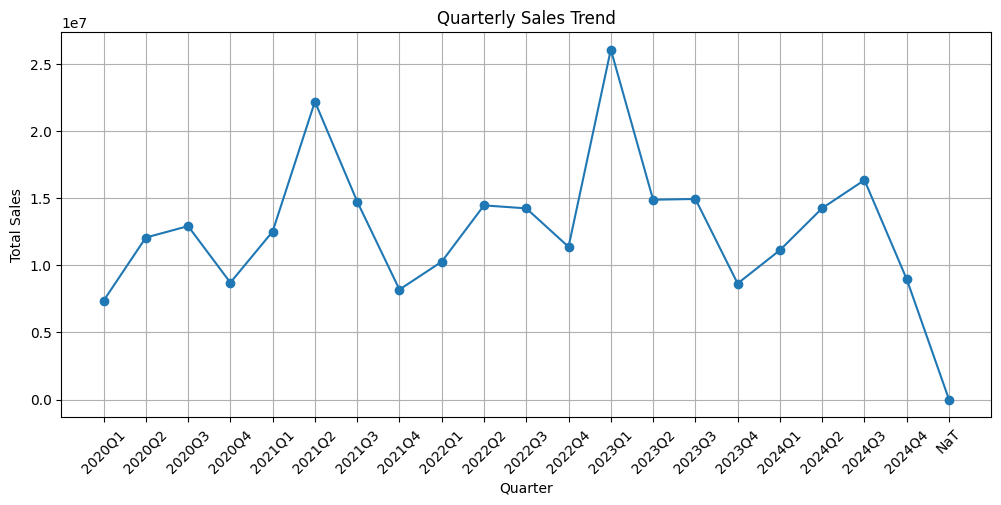

In [ ]:
df["Quarter"] = df["order_date"].dt.to_period("Q").astype(str)

quarterly_sales = df.groupby("Quarter")["sales_amount"].sum()

plt.figure(figsize=(12,5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Observation

The quarterly analysis provides a broader view of sales performance and helps identify quarters with comparatively higher or lower revenue.

# 9. Customer Age Group Analysis

Customers are divided into different age groups to understand the distribution of customers across age ranges.

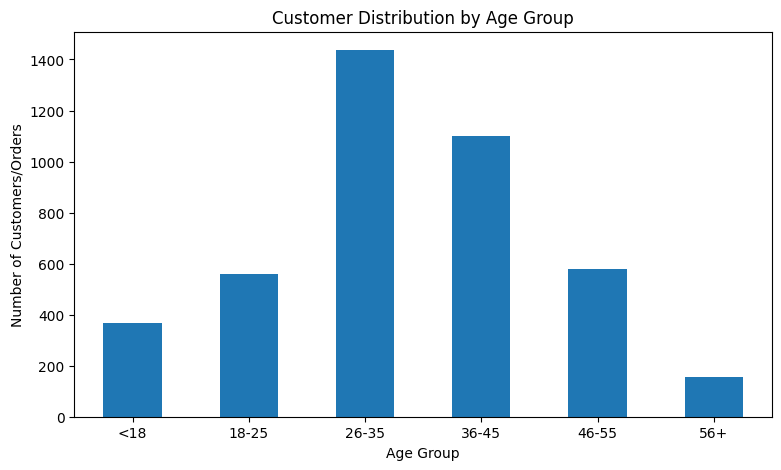

In [ ]:
bins = [0, 18, 25, 35, 45, 55, 100]

labels = [
    "<18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

df["Age_Group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

age_counts = df["Age_Group"].value_counts().sort_index()

plt.figure(figsize=(9,5))

age_counts.plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers/Orders")
plt.xticks(rotation=0)

plt.show()

### Observation

The age-group analysis shows how customers/orders are distributed across different age ranges. The most represented age group can help businesses target their marketing strategies more effectively.

# 10. Gender Distribution

The gender distribution is analyzed to understand the composition of customers/orders.

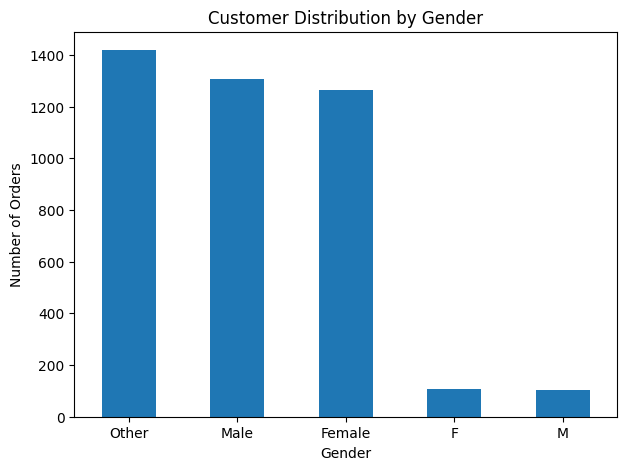

In [ ]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7,5))

gender_counts.plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.show()

### Observation

The gender distribution shows the relative representation of different gender categories in the dataset. This information can support customer segmentation and targeted marketing.

# 11. Top 10 Best-Selling Products

The top 10 products are identified based on total quantity sold.

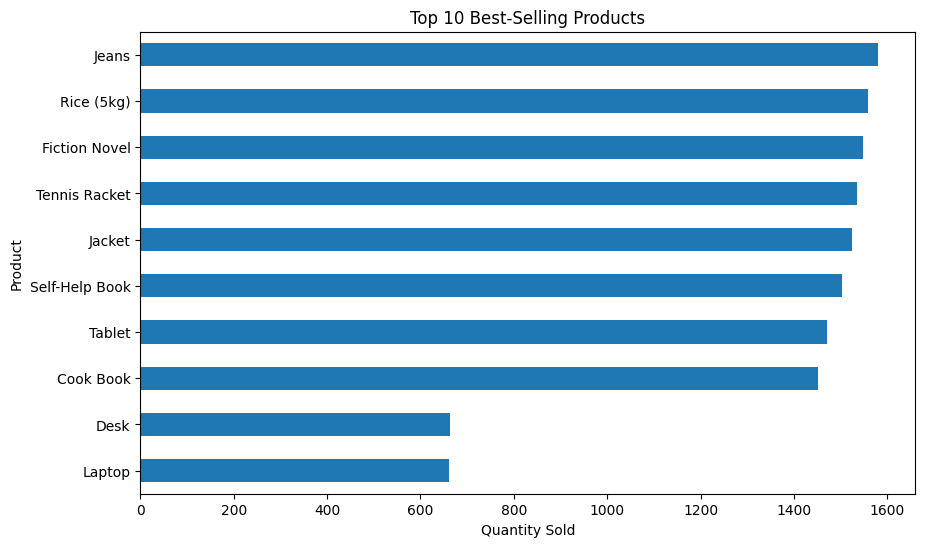

In [ ]:
top_10_products = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_10_products.sort_values().plot(kind="barh")

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

### Observation

The Top 10 analysis identifies the products with the highest sales volume. These products should receive appropriate inventory planning to reduce the possibility of stock shortages.

# 12. Revenue by Product Category

Total revenue is calculated for each product category to identify the strongest revenue-generating categories.

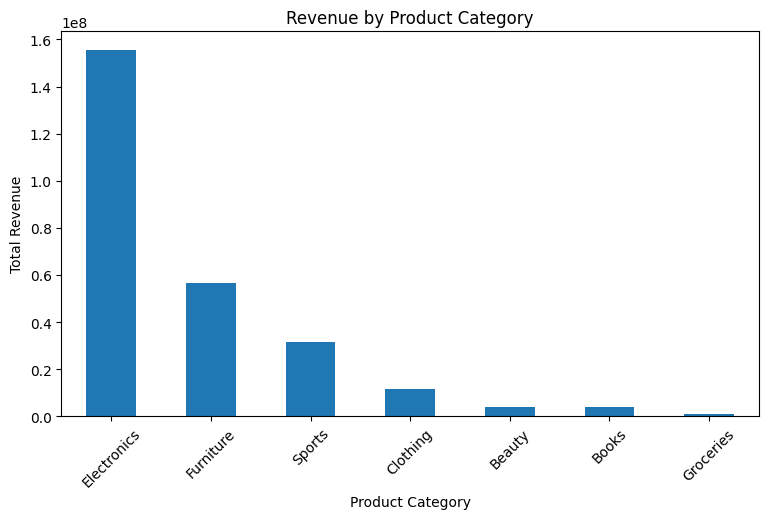

In [ ]:
category_revenue = (
    df.groupby("product_category")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

### Observation

The category revenue analysis shows which product categories contribute the most to total sales revenue. High-performing categories can receive greater inventory and marketing attention.

# 13. Correlation Analysis

A correlation matrix is used to examine relationships between numerical variables in the dataset.

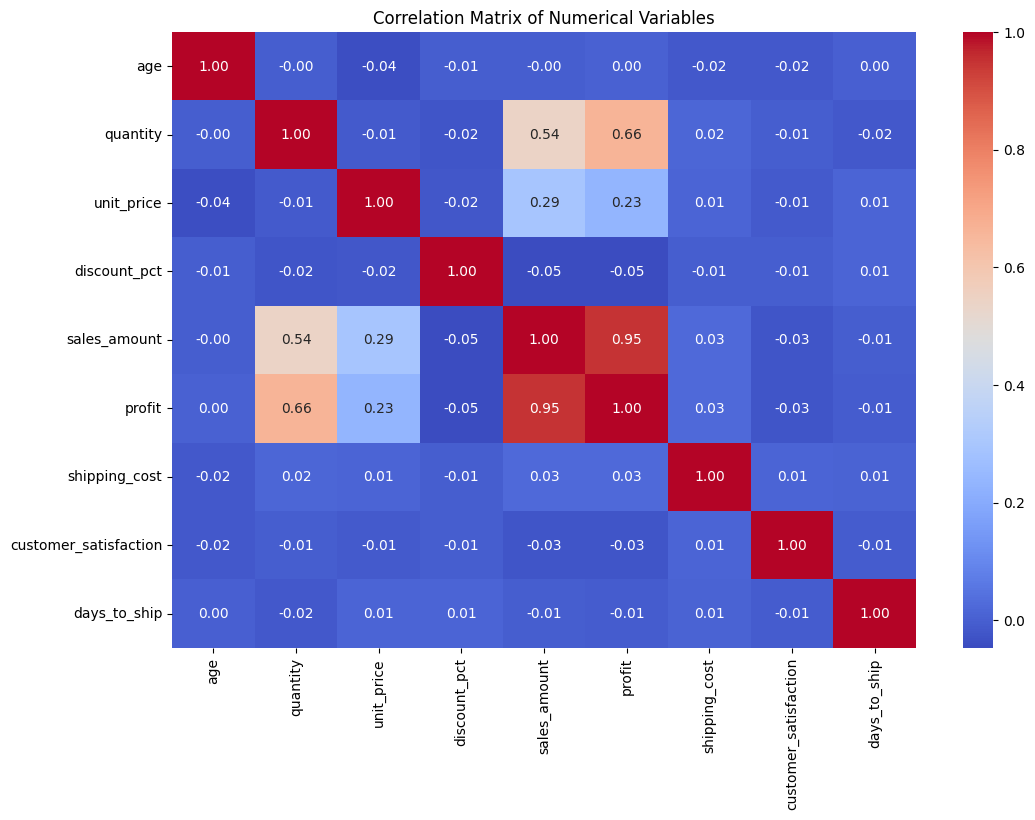

In [ ]:
numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships between numerical variables. Positive values indicate variables tend to increase together, while negative values indicate an inverse relationship. Correlation does not necessarily imply causation.

# 14. Additional Visualization: Discount vs Profit

A scatter plot is used to investigate whether discount levels show any visible relationship with profit.

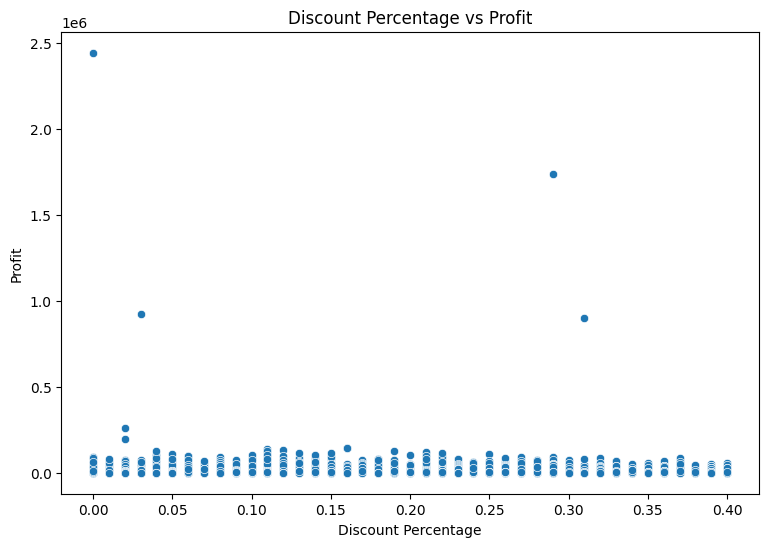

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="discount_pct",
    y="profit"
)

plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

plt.show()

### Observation

The scatter plot helps visualize the relationship between discount percentage and profit. The distribution of points can indicate whether higher discounts are associated with changes in profit. Further statistical analysis would be required to establish a strong relationship.

# 15. Overall Observations

The EDA provided several useful insights:

1. Monthly and quarterly analysis shows variations in sales performance over time.
2. Customer demographics reveal the distribution of customers across age groups and genders.
3. The Top 10 product analysis identifies products with high sales volume.
4. Category-level revenue analysis highlights the major revenue-generating product categories.
5. The correlation heatmap helps identify relationships among numerical variables.
6. The discount-versus-profit analysis provides an additional view of promotional effectiveness.

# 16. Conclusion

The Exploratory Data Analysis of the retail sales dataset provided useful insights into sales trends, customer demographics, product performance, and relationships among numerical variables.

The analysis included data inspection and cleaning, descriptive statistics, monthly and quarterly sales trends, customer age-group and gender analysis, top-selling products, revenue by product category, correlation analysis, and an additional discount-versus-profit visualization.

Overall, EDA helps transform raw retail data into meaningful information that can support better business decisions related to inventory, marketing, customer segmentation, and promotional strategies.

# 17. Business Recommendations

Based on the EDA, the following recommendations can be considered:

### 1. Inventory Optimization
Maintain sufficient inventory for high-demand products identified through the Top 10 product analysis.

### 2. Category Strategy
Give greater marketing and inventory attention to high-revenue product categories while reviewing underperforming categories.

### 3. Seasonal Planning
Use monthly and quarterly sales trends to plan inventory, promotions, and marketing campaigns during high-demand periods.

### 4. Customer Segmentation
Use age-group and gender distribution to develop more targeted customer marketing strategies.

### 5. Discount Management
Monitor the relationship between discounts and profit to ensure promotional campaigns support revenue without unnecessarily reducing profitability.